In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)
library(nationalparkcolors)
library(vroom)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


In [2]:
cred.set <- vroom('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.credset.hg38.tsv', 
                        delim='\t')
dim(cred.set)
head(cred.set)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 847 Columns: 19
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (8): CS.Type, LEAD.SNP, CS.SNP, EA, NEA, PP, Nominated.Gene, Biological...
dbl (10): Chr, Position, EAF, Beta, SE, P, N, chr.hg38, start.hg38, end.hg38
lgl  (1): Not.in.Trans.Ethnic

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 847  19

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,Not.in.Trans.Ethnic,chr.hg38,start.hg38,end.hg38
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>
Single SNP,rs2642438,rs2642438,1,220970028,A,G,0.295,-0.079,0.0080,0.00e+00,164197,99.54%,MTARC1,MTARC1,NA,1,220796685,220796686
NA,rs74816838,rs74816838,1,161643560,T,C,0.112,0.087,0.0128,1.09e-11,164197,96.21%,FCGR2A;FCGR2B,FCGR2A;FCGR2B,NA,1,161673769,161673770
NA,rs147998249,rs147998249,8,145732180,C,G,0.003,-2.019,0.1230,0.00e+00,164197,100.00%,GPT,GPT,NA,8,144506796,144506797
NA,rs2954038,rs2954038,8,126507389,C,A,0.306,0.139,0.0079,0.00e+00,164197,99.99%,lnc-TRIB1-2;WASHC5,TRIB1,NA,8,125495146,125495147
NA,rs10883451,rs10883451,10,101924418,C,T,0.477,-0.161,0.0073,0.00e+00,164197,98.90%,ERLIN1,ERLIN1,NA,10,100164660,100164661
NA,rs11601507,rs11601507,11,5701074,A,C,0.073,0.088,0.0139,2.16e-10,164197,99.82%,TRIM5,TRIM5,NA,11,5679843,5679844


In [3]:
cred.lead <- select(cred.set, LEAD.SNP, Biological.Prior.Gene) %>%
    distinct()

cred.lead$Gene <- str_split_fixed(cred.lead$Biological.Prior.Gene, ";", n = 2)[,1]
cred.lead <- select(cred.lead, -Biological.Prior.Gene)
dim(cred.lead)
head(cred.lead)

[1] 55  2

LEAD.SNP,Gene
<chr>,<chr>
rs2642438,MTARC1
rs74816838,FCGR2A
rs147998249,GPT
rs2954038,TRIB1
rs10883451,ERLIN1
rs11601507,TRIM5


In [4]:
str_split_fixed(cred.lead$Biological.Prior.Gene, ";", n = 2)[,1]

Warning message:
“Unknown or uninitialised column: `Biological.Prior.Gene`.”


character(0)

In [5]:
sum.stats <- vroom('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.hg38.tsv', 
                        delim='\t')
dim(sum.stats)
head(sum.stats)

Rows: 11657625 Columns: 13
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): RSID, EA, NEA
dbl (10): CHR, POS, EAF, BETA, SE, P, N, OR, chr.hg38, pos.hg38

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 11657625       13

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186


In [6]:
sum.stats.lead <- left_join(sum.stats, cred.lead, by=join_by(RSID==LEAD.SNP))

sum(!is.na(sum.stats.lead$Gene))
dim(sum.stats.lead)
head(sum.stats.lead)

[1] 55

[1] 11657625       14

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38,Gene
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511,NA
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782,NA
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952,NA
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963,NA
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376,NA
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186,NA


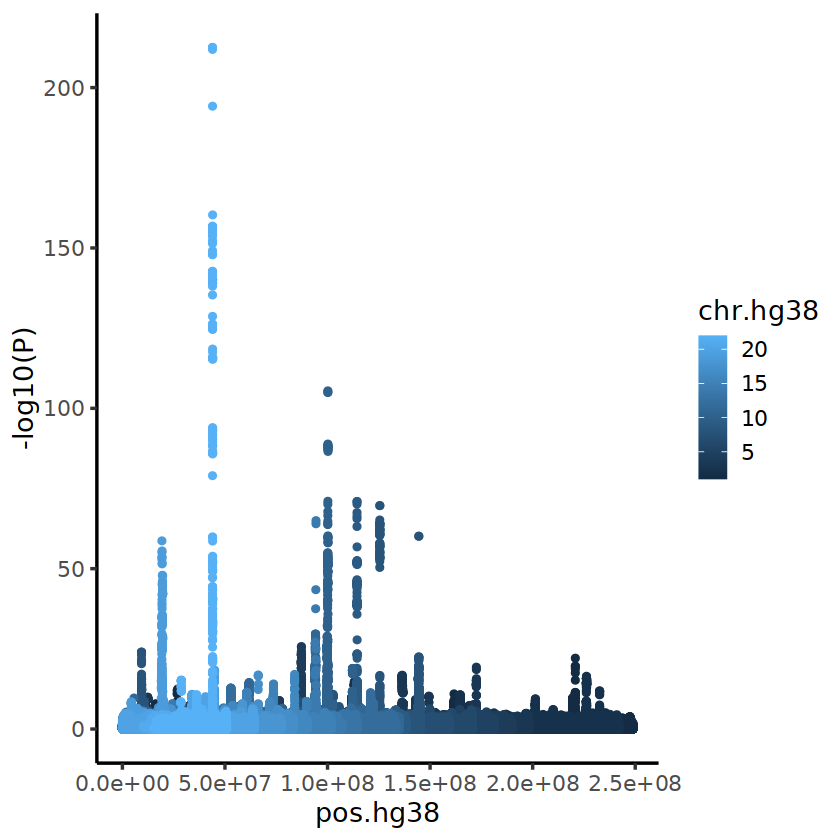

In [10]:
ggplot(sum.stats, aes(x=pos.hg38,y=-log10(P),color=chr.hg38)) + 
    geom_point() +
    theme_classic(base_size=16) 

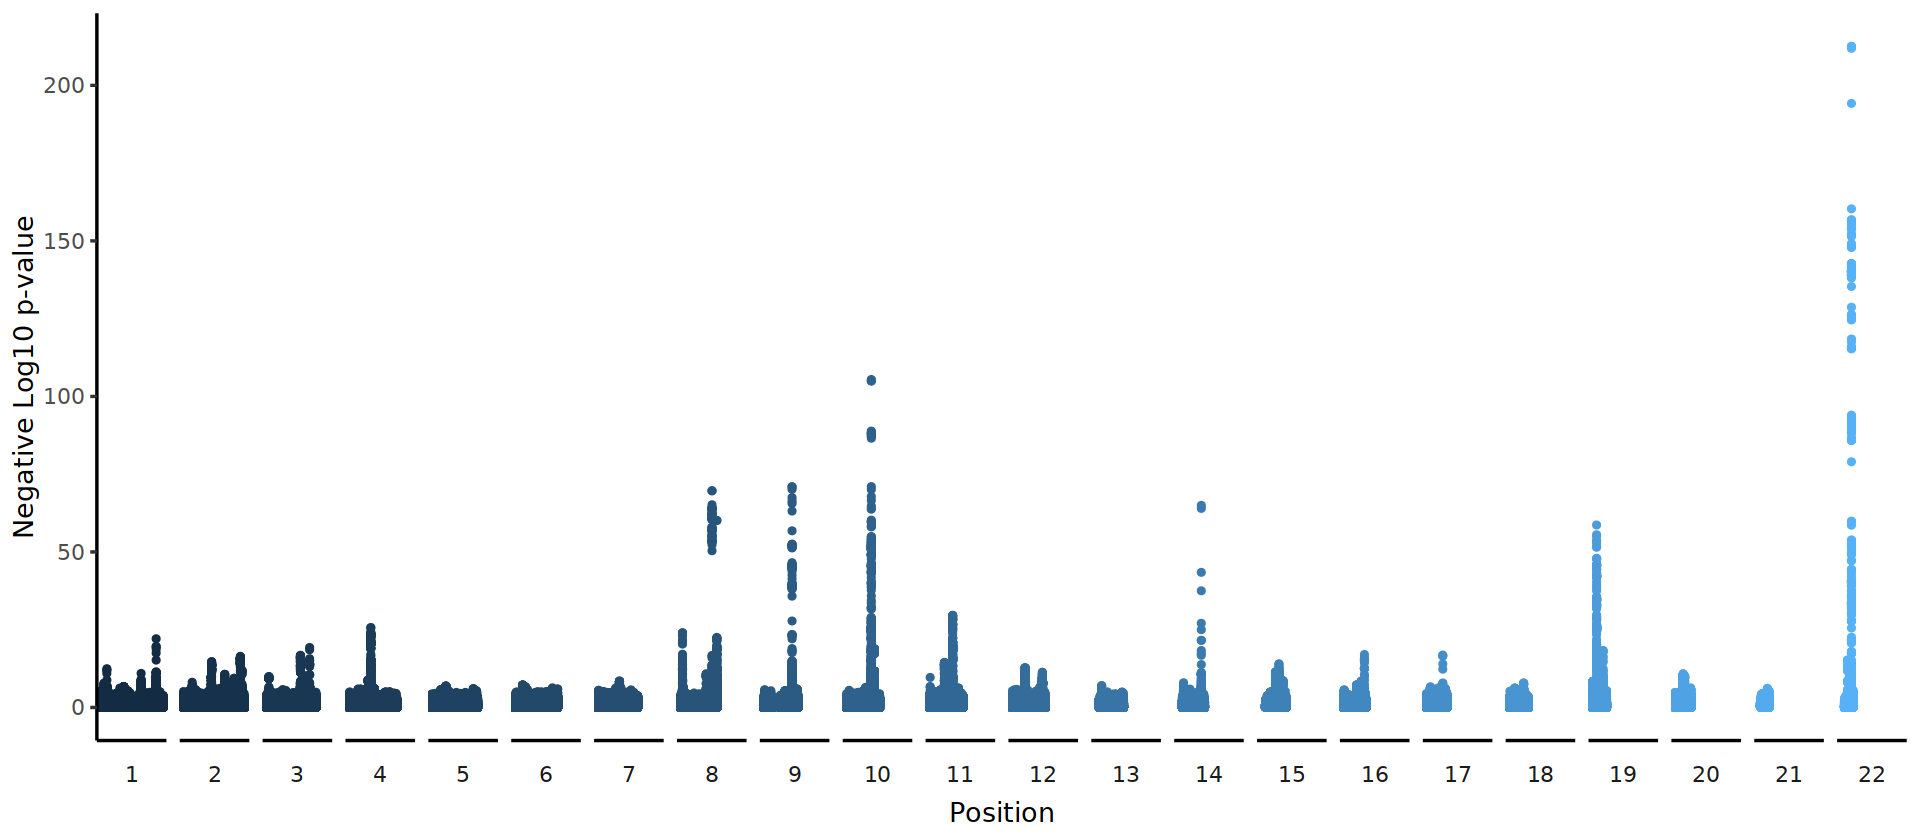

In [16]:
options(repr.plot.width=16)

ggplot(sum.stats, aes(x=pos.hg38,y=-log10(P),color=chr.hg38)) + 
    geom_point() +
    theme_classic(base_size=16) +
    facet_grid(~chr.hg38, switch = "x") +
    labs(y='Negative Log10 p-value', x='Chromosome') +
    theme(
        strip.placement = "outside",       # Position the strip labels outside the plot area
        strip.background = element_blank(), # Remove strip background color
        legend.position = "none",           # Remove legend
        axis.text.x = element_blank(),      # Remove x-axis text
        axis.ticks.x = element_blank()      # Remove x-axis ticks
    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) 

In [5]:
rep(park_palette("Acadia")[c(4,2)], times = 11)

[1] "#476F84" "#023743" "#476F84" "#023743" "#476F84" "#023743" "#476F84"
 [8] "#023743" "#476F84" "#023743" "#476F84" "#023743" "#476F84" "#023743"
[15] "#476F84" "#023743" "#476F84" "#023743" "#476F84" "#023743" "#476F84"
[22] "#023743"

In [6]:
sum.stats$chr.hg38 <- factor(as.character(sum.stats$chr.hg38), levels=1:22)

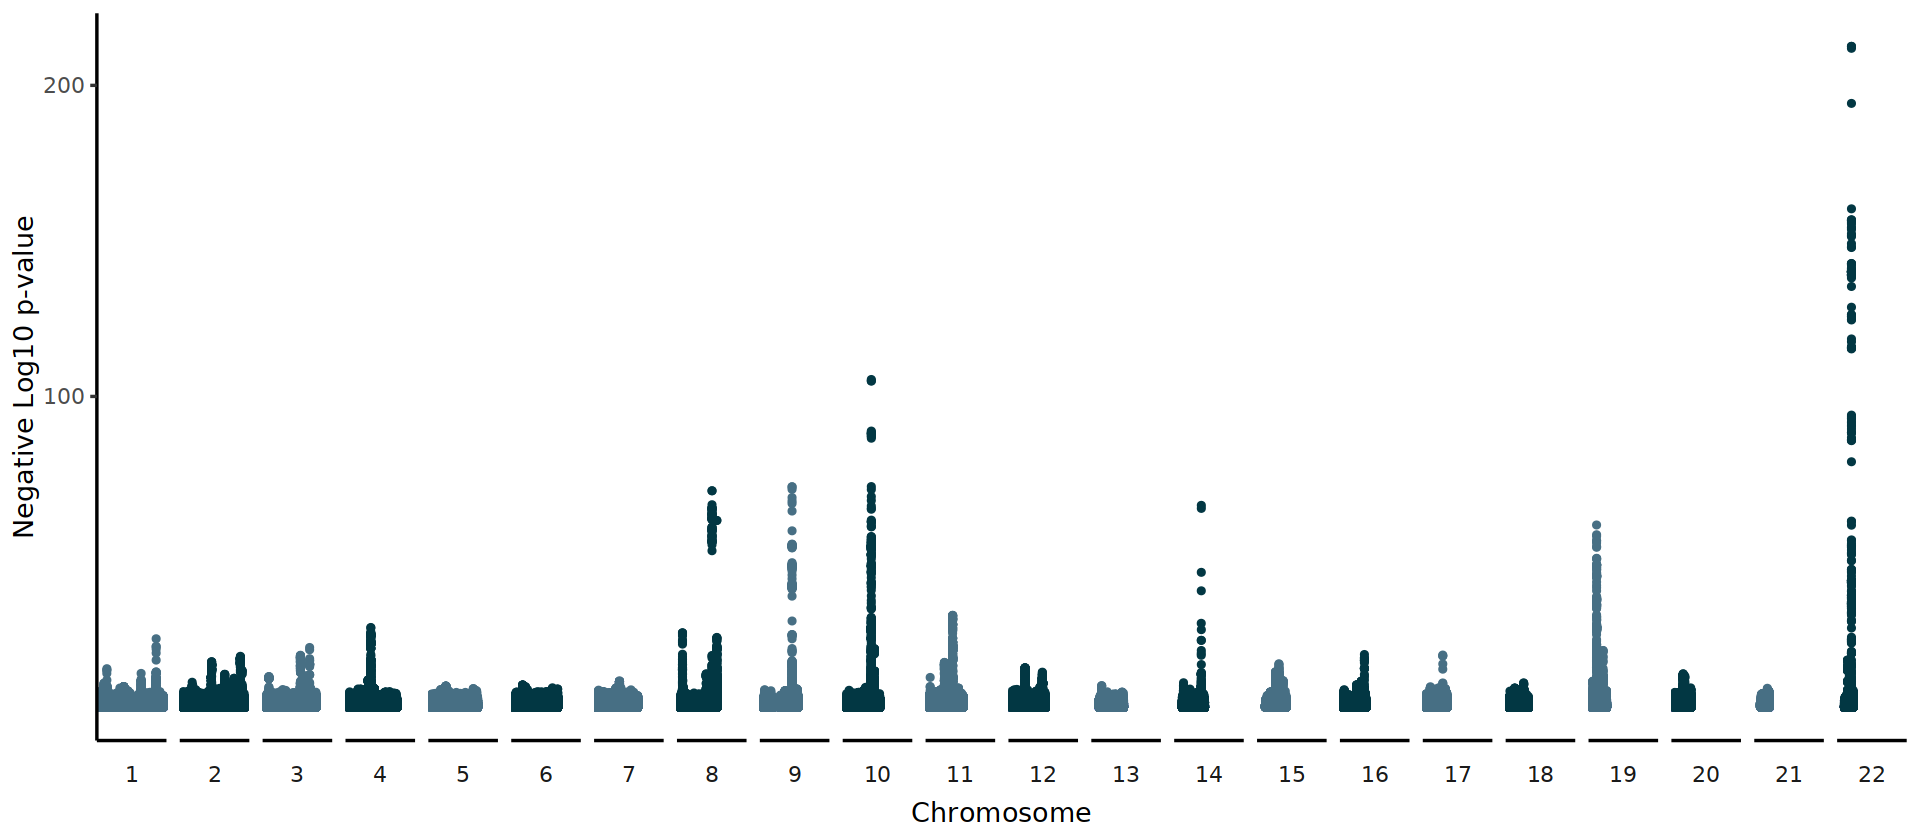

In [7]:
options(repr.plot.width=16)

ggplot(sum.stats, aes(x=pos.hg38,y=-log10(P),color=chr.hg38)) + 
    geom_point() +
    theme_classic(base_size=16) +
    facet_grid(~chr.hg38, switch = "x") +
    labs(y='Negative Log10 p-value', x='Chromosome') +
    theme(
        strip.placement = "outside",       # Position the strip labels outside the plot area
        strip.background = element_blank(), # Remove strip background color
        legend.position = "none",           # Remove legend
        axis.text.x = element_blank(),      # Remove x-axis text
        axis.ticks.x = element_blank()      # Remove x-axis ticks
    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) +
    scale_y_continuous(breaks=c(100,200))

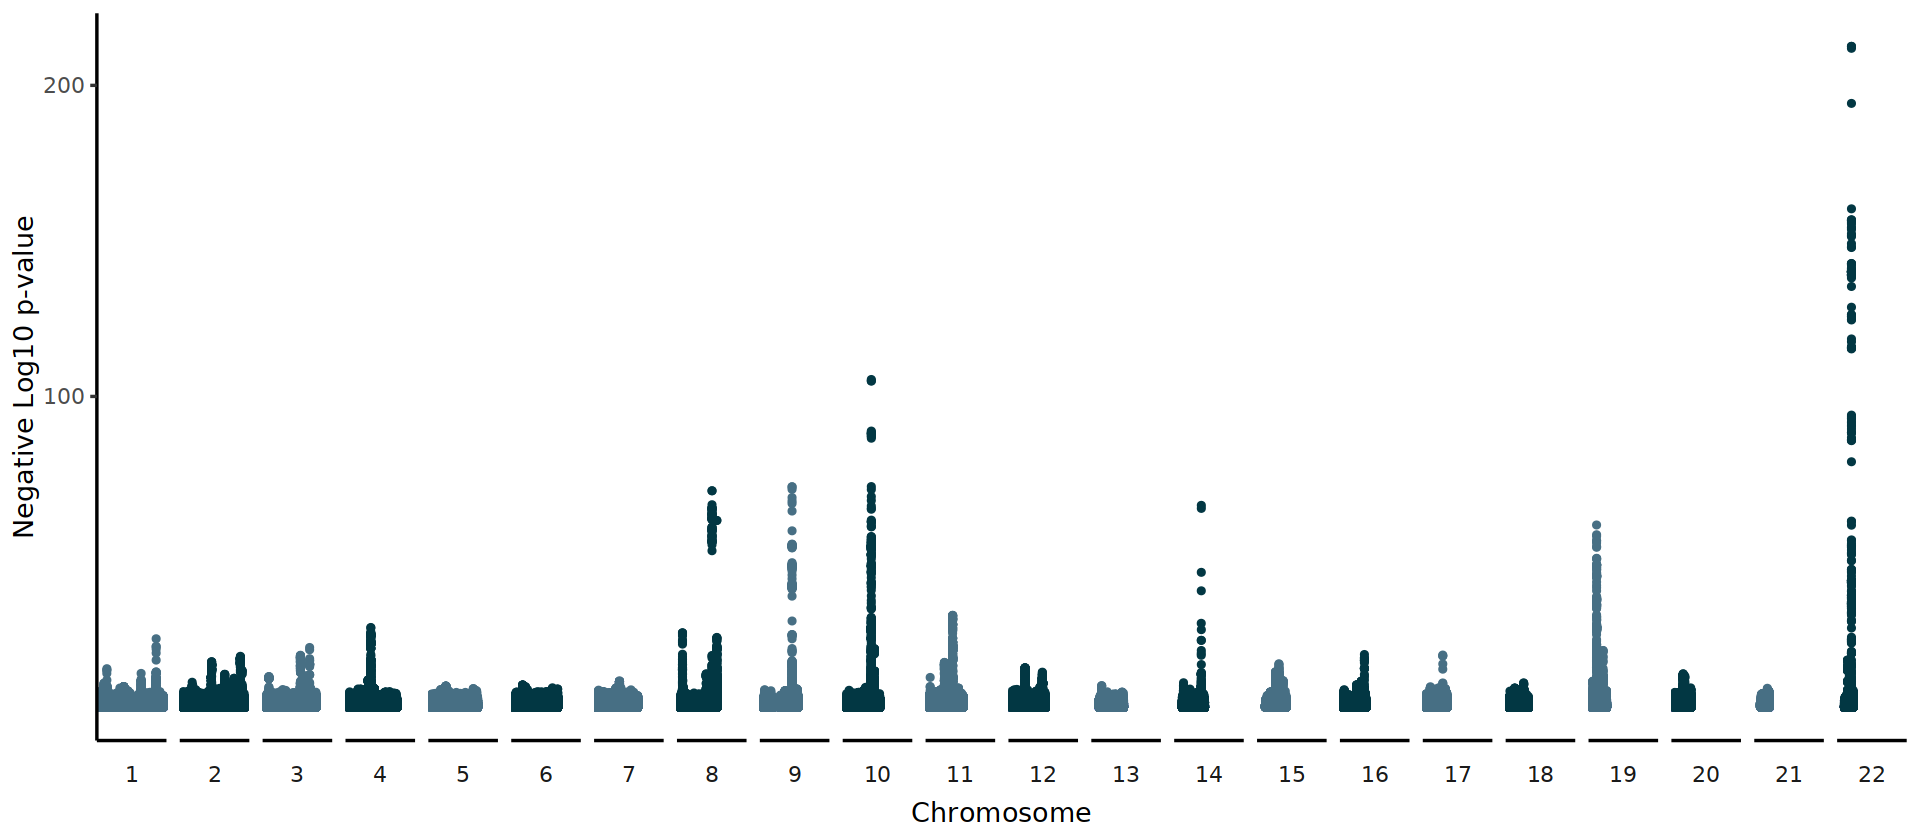

In [26]:
options(repr.plot.width=16)

ggplot(sum.stats, aes(x=pos.hg38,y=-log10(P),color=chr.hg38)) + 
    geom_point() +
    theme_classic(base_size=16) +
    facet_grid(~chr.hg38, switch = "x") +
    labs(y='Negative Log10 p-value', x='Chromosome') +
    theme(
        strip.placement = "outside",       # Position the strip labels outside the plot area
        strip.background = element_blank(), # Remove strip background color
        legend.position = "none",           # Remove legend
        axis.text.x = element_blank(),      # Remove x-axis text
        axis.ticks.x = element_blank()      # Remove x-axis ticks
    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) +
    scale_y_continuous(breaks=c(100,200))

In [27]:
library(ggrepel)

Warning message:
“package ‘ggrepel’ was built under R version 4.3.2”


In [31]:
options(repr.plot.width=16)

ggplot(sum.stats.lead, aes(x=pos.hg38,y=-log10(P),color=chr.hg38, label=Gene)) + 
    geom_point() +
    theme_classic(base_size=16) +
    facet_grid(~chr.hg38, switch = "x") +
    labs(y='Negative Log10 p-value', x='Chromosome') +
    theme(
        strip.placement = "outside",       # Position the strip labels outside the plot area
        strip.background = element_blank(), # Remove strip background color
        legend.position = "none",           # Remove legend
        axis.text.x = element_blank(),      # Remove x-axis text
        axis.ticks.x = element_blank()      # Remove x-axis ticks
    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)

Warning message:
“Removed 11657570 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


Warning message:
“Removed 11657570 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


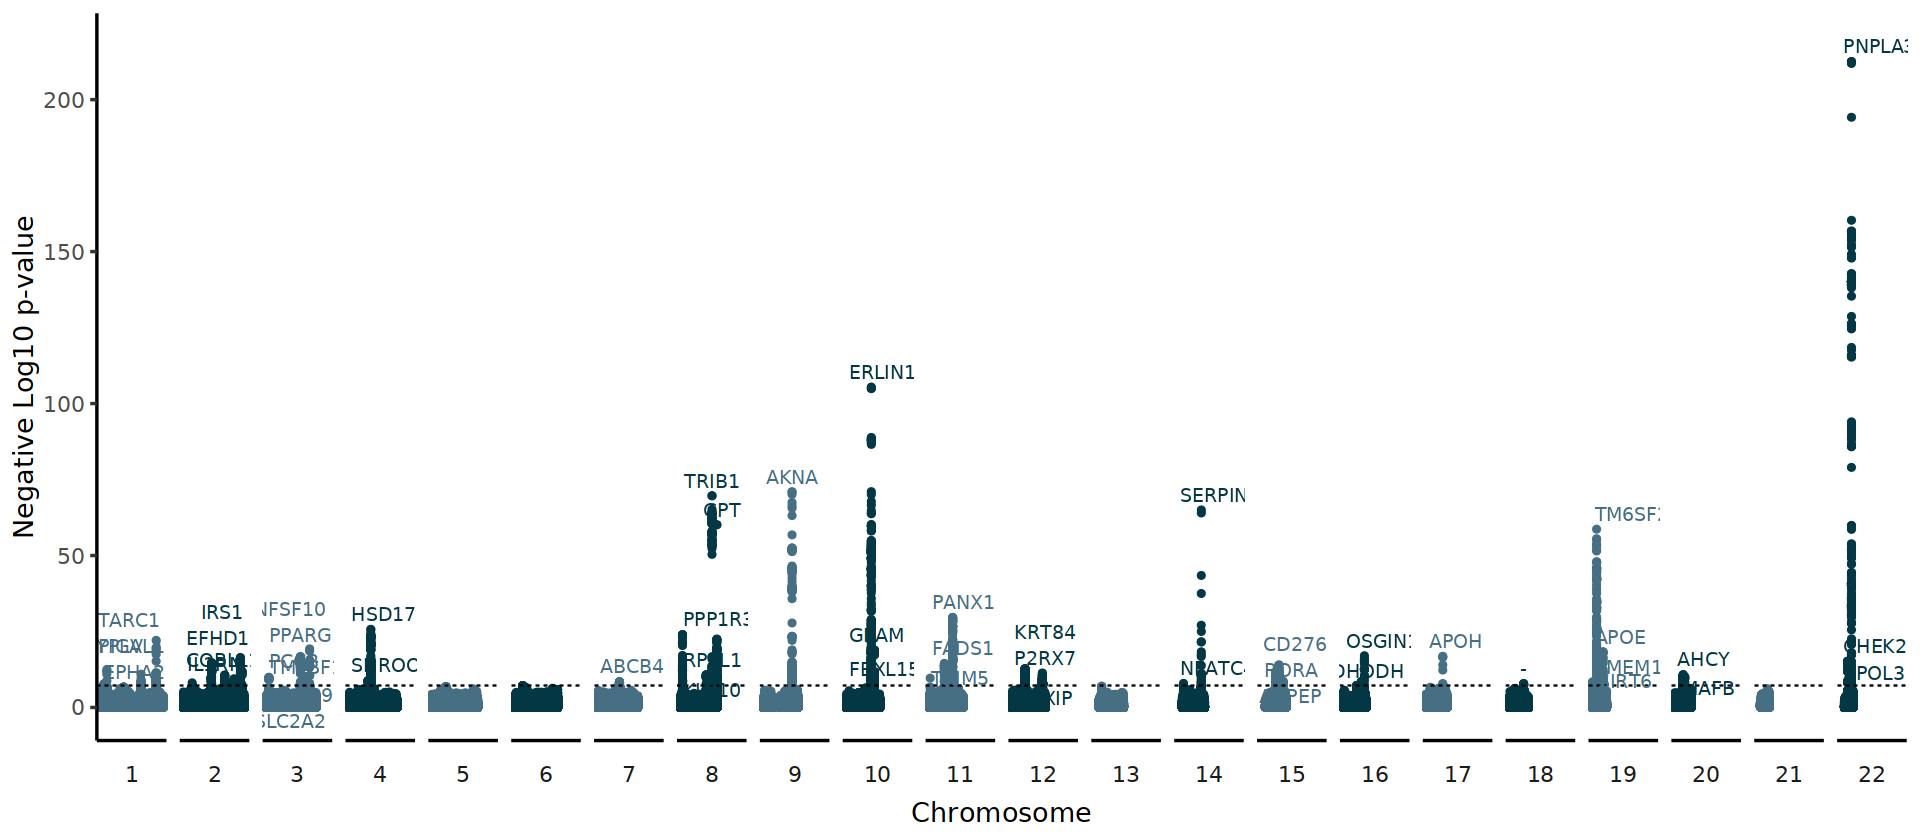

In [30]:
options(repr.plot.width=16)

ggplot(sum.stats.lead, aes(x=pos.hg38,y=-log10(P),color=chr.hg38, label=Gene)) + 
    geom_point() +
    theme_classic(base_size=16) +
    facet_grid(~chr.hg38, switch = "x") +
    labs(y='Negative Log10 p-value', x='Chromosome') +
    theme(
        strip.placement = "outside",       # Position the strip labels outside the plot area
        strip.background = element_blank(), # Remove strip background color
        legend.position = "none",           # Remove legend
        axis.text.x = element_blank(),      # Remove x-axis text
        axis.ticks.x = element_blank()      # Remove x-axis ticks
    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 5)

Warning message:
“Removed 778438 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


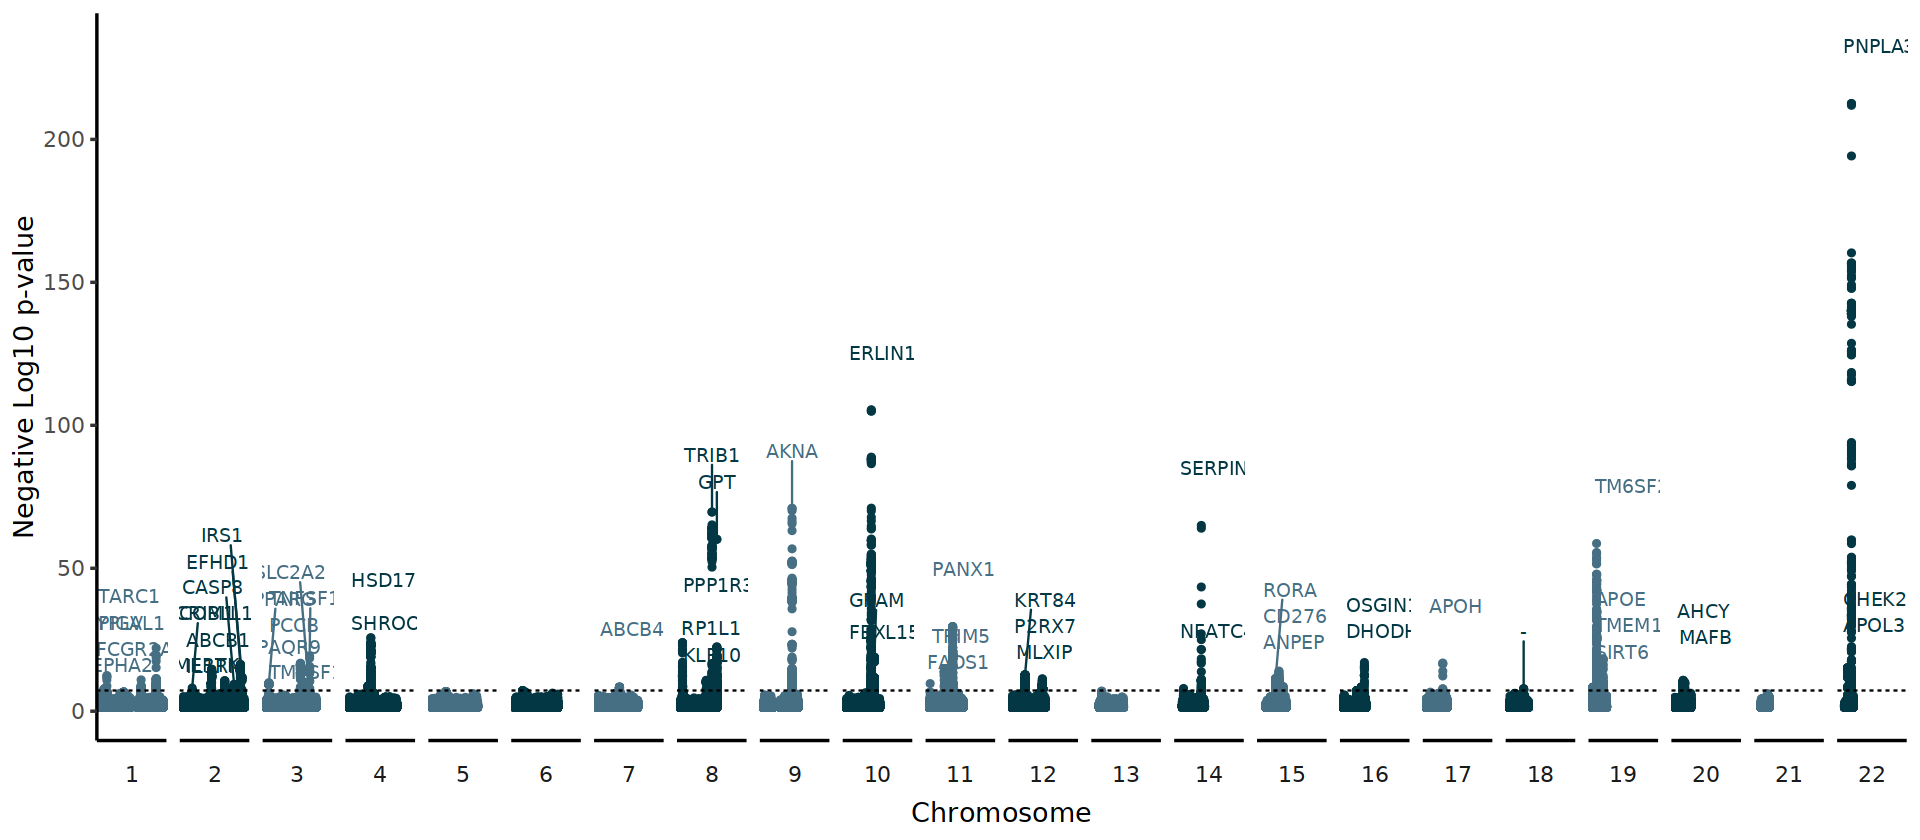

In [32]:
options(repr.plot.width=16)

ggplot(filter(sum.stats.lead,P < 0.005), aes(x=pos.hg38,y=-log10(P),color=chr.hg38, label=Gene)) + 
    geom_point() +
    theme_classic(base_size=16) +
    facet_grid(~chr.hg38, switch = "x") +
    labs(y='Negative Log10 p-value', x='Chromosome') +
    theme(
        strip.placement = "outside",       # Position the strip labels outside the plot area
        strip.background = element_blank(), # Remove strip background color
        legend.position = "none",           # Remove legend
        axis.text.x = element_blank(),      # Remove x-axis text
        axis.ticks.x = element_blank()      # Remove x-axis ticks
    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)

In [33]:
head(sum.stats.lead)

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38,Gene
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<chr>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511,NA
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782,NA
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952,NA
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963,NA
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376,NA
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186,NA


In [39]:
don <- sum.stats.lead %>% 
  
  # Compute chromosome size
  group_by(CHR) %>% 
  summarise(chr_len=max(POS)) %>% 
  
  # Calculate cumulative position of each chromosome
  mutate(tot=cumsum(chr_len)-chr_len) %>%
  select(-chr_len) %>%
  
  # Add this info to the initial dataset
  left_join(sum.stats.lead, ., by=c("CHR"="CHR")) %>%
  
  # Add a cumulative position of each SNP
  arrange(CHR, POS) %>%
  mutate( BPcum=POS+tot)

axisdf = don %>%
  group_by(CHR) %>%
  summarize(center=( max(BPcum) + min(BPcum) ) / 2 )

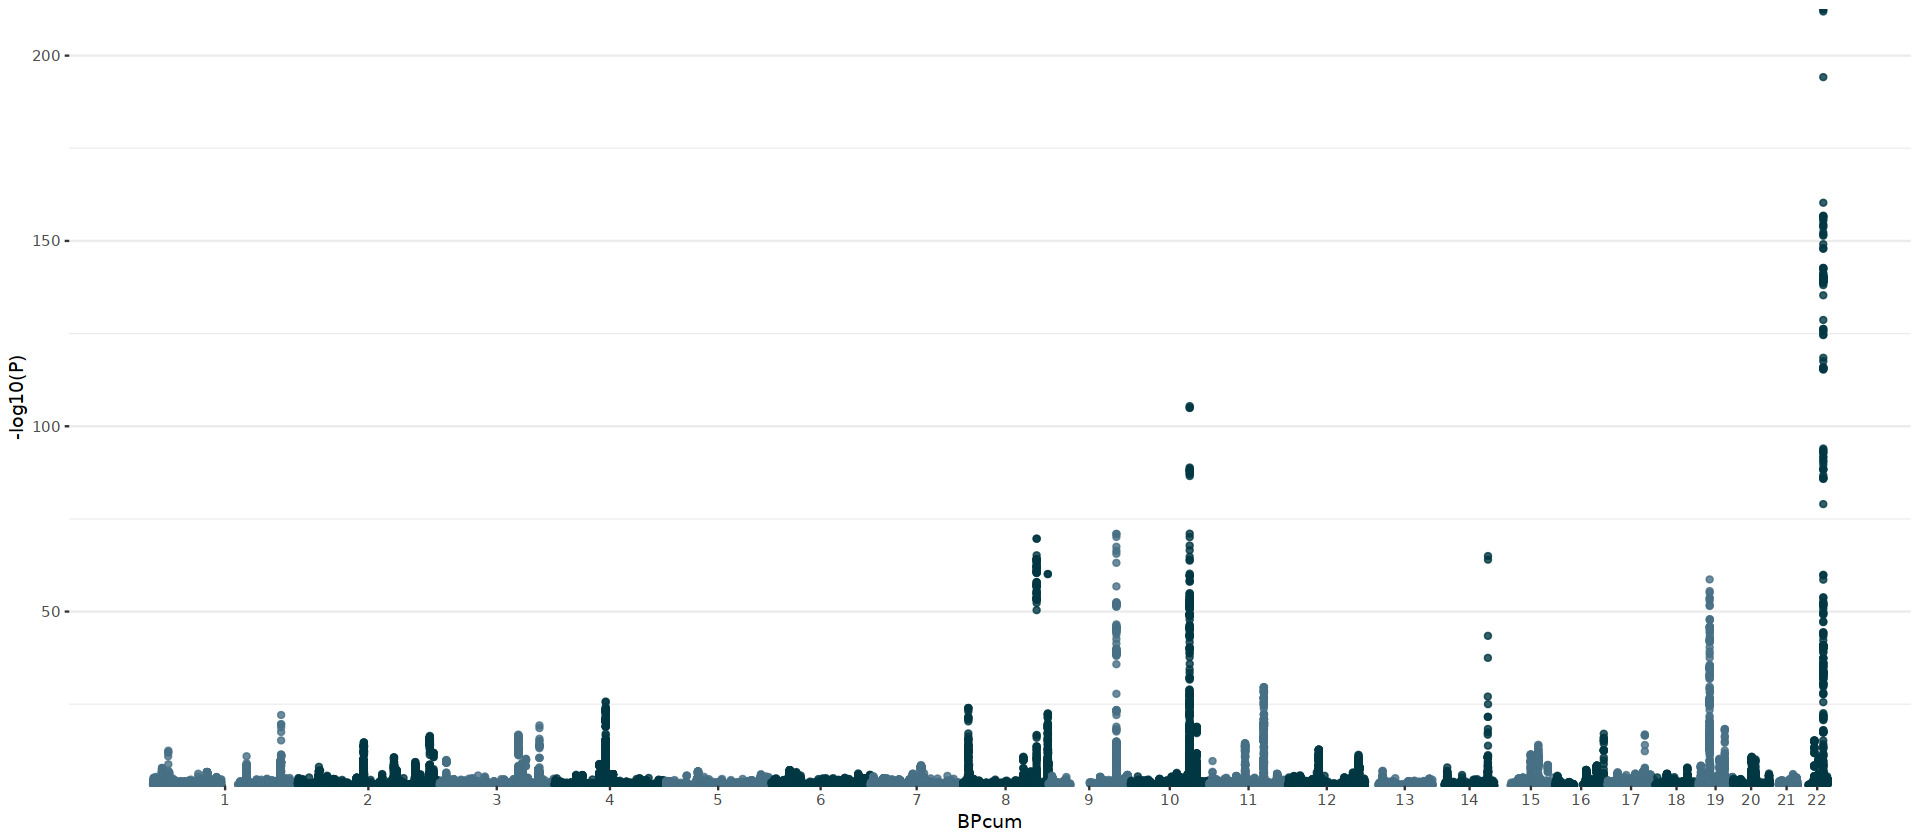

In [36]:
ggplot(filter(don, P < 0.001), aes(x=BPcum, y=-log10(P))) +
    
    # Show all points
    geom_point( aes(color=as.factor(CHR)), alpha=0.8, size=1.3) +
    scale_color_manual(values = rep(park_palette("Acadia")[c(4,2)], 22 )) +
    
    # custom X axis:
    scale_x_continuous( label = axisdf$CHR, breaks= axisdf$center ) +
    scale_y_continuous(expand = c(0, 0) ) +     # remove space between plot area and x axis
  
    # Custom the theme:
    theme_classic(base_size=16) +
    theme( 
      legend.position="none",
      panel.border = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank()
    ) +
    
    labs(y='Negative log10 p.value', x='Chromosome') +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)

Warning message:
“Removed 46555 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“ggrepel: 15 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


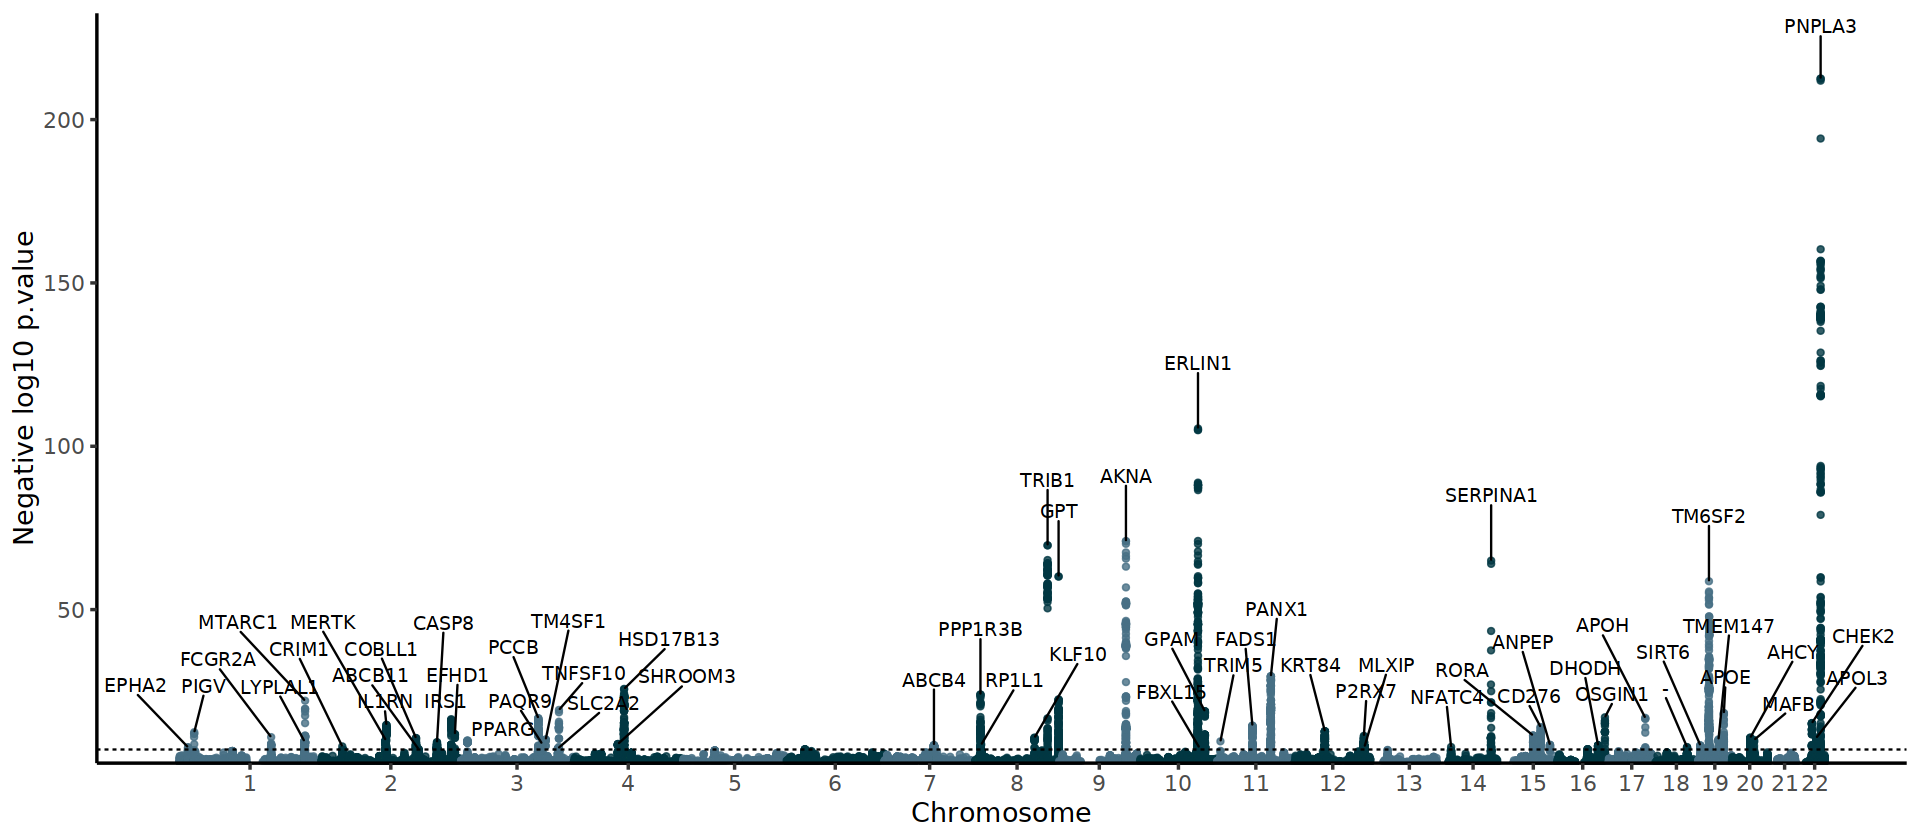

In [37]:
ggplot(filter(don, P < 0.001), aes(x=BPcum, y=-log10(P), label=Gene)) +
    
    # Show all points
    geom_point( aes(color=as.factor(CHR)), alpha=0.8, size=1.3) +
    scale_color_manual(values = rep(park_palette("Acadia")[c(4,2)], 22 )) +
    
    # custom X axis:
    scale_x_continuous( label = axisdf$CHR, breaks= axisdf$center ) +
    scale_y_continuous(expand = c(0, 0) ) +     # remove space between plot area and x axis
  
    # Custom the theme:
    theme_classic(base_size=16) +
    theme( 
      legend.position="none",
      panel.border = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank()
    ) +
    
    labs(y='Negative log10 p.value', x='Chromosome') +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)

Warning message:
“Removed 46589 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


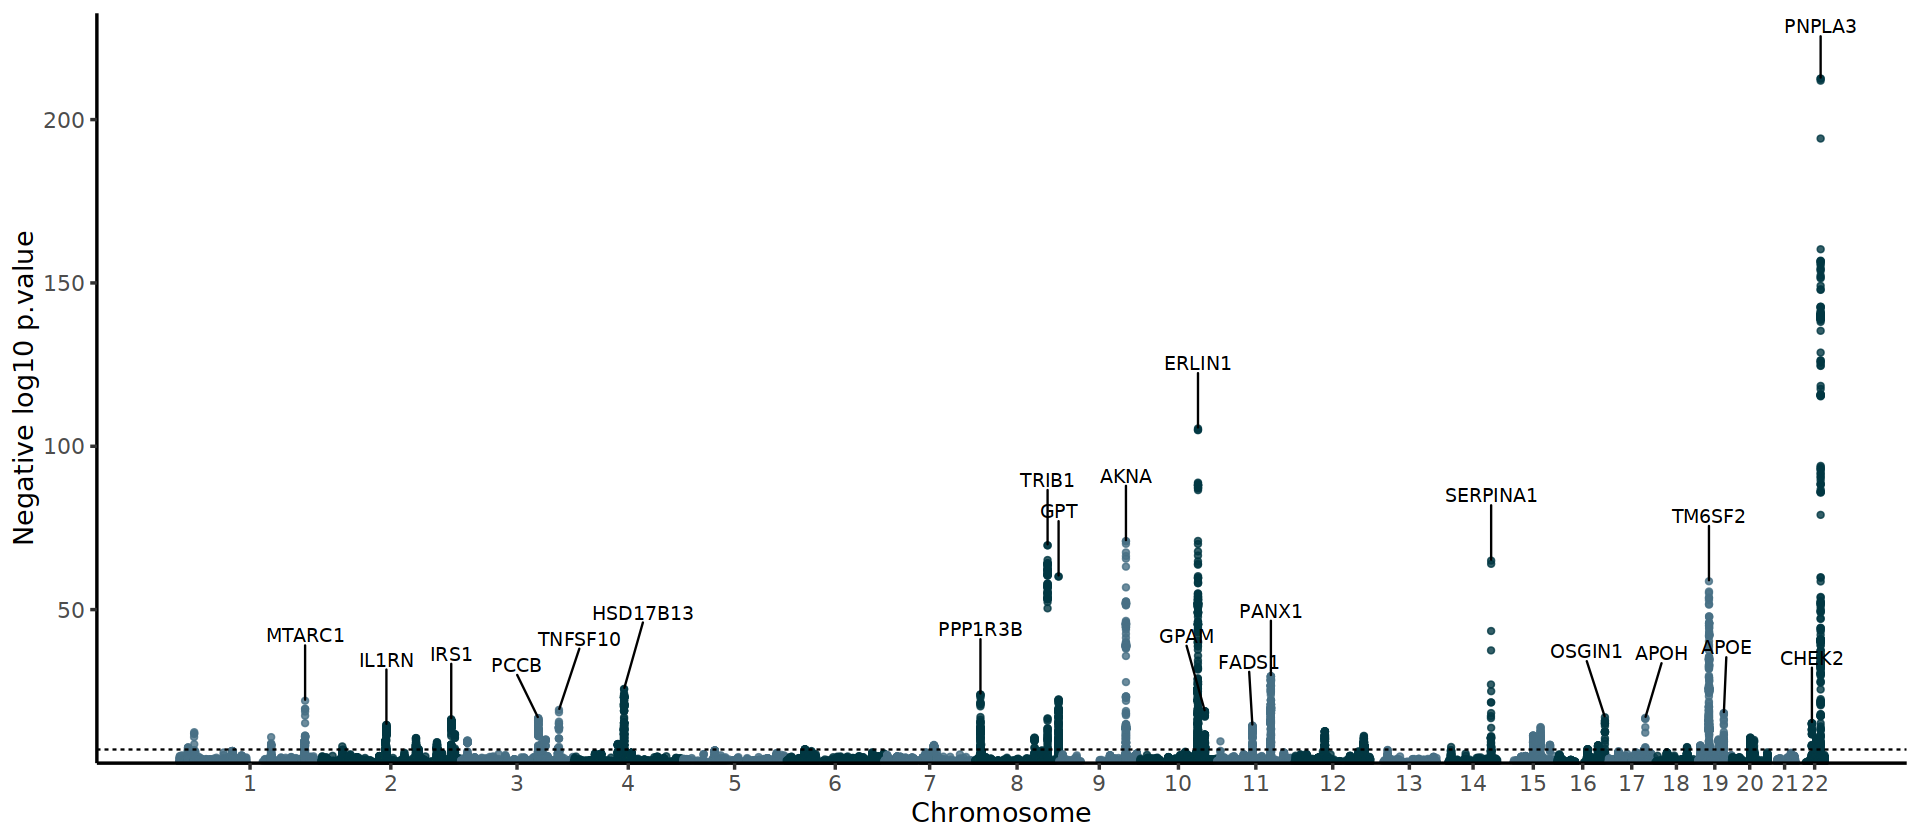

In [40]:
don[don$P > 5e-15,]$Gene <- NA

ggplot(filter(don, P < 0.001), aes(x=BPcum, y=-log10(P), label=Gene)) +
    
    # Show all points
    geom_point( aes(color=as.factor(CHR)), alpha=0.8, size=1.3) +
    scale_color_manual(values = rep(park_palette("Acadia")[c(4,2)], 22 )) +
    
    # custom X axis:
    scale_x_continuous( label = axisdf$CHR, breaks= axisdf$center ) +
    scale_y_continuous(expand = c(0, 0) ) +     # remove space between plot area and x axis
  
    # Custom the theme:
    theme_classic(base_size=16) +
    theme( 
      legend.position="none",
      panel.border = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank()
    ) +
    
    labs(y='Negative log10 p.value', x='Chromosome') +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)

In [7]:
gtf <- read.table('/nfs/lab/elisha/scripts/refdata-gex-GRCh38-2020-A/genes/genes.gtf.gz', sep='\t')

dim(gtf)
head(gtf)

[1] 2765969       9

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,chr1,HAVANA,gene,29554,31109,.,+,.,gene_id ENSG00000243485; gene_version 5; gene_type lncRNA; gene_name MIR1302-2HG; level 2; hgnc_id HGNC:52482; tag ncRNA_host; havana_gene OTTHUMG00000000959.2;
2,chr1,HAVANA,transcript,29554,31097,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
3,chr1,HAVANA,exon,29554,30039,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; exon_number 1; exon_id ENSE00001947070; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
4,chr1,HAVANA,exon,30564,30667,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; exon_number 2; exon_id ENSE00001922571; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
5,chr1,HAVANA,exon,30976,31097,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; exon_number 3; exon_id ENSE00001827679; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
6,chr1,HAVANA,transcript,30267,31109,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000469289; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-201; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002841.2;


In [8]:
gtf

V1,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,HAVANA,gene,29554,31109,.,+,.,gene_id ENSG00000243485; gene_version 5; gene_type lncRNA; gene_name MIR1302-2HG; level 2; hgnc_id HGNC:52482; tag ncRNA_host; havana_gene OTTHUMG00000000959.2;
chr1,HAVANA,transcript,29554,31097,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
chr1,HAVANA,exon,29554,30039,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; exon_number 1; exon_id ENSE00001947070; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
chr1,HAVANA,exon,30564,30667,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; exon_number 2; exon_id ENSE00001922571; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
chr1,HAVANA,exon,30976,31097,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000473358; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-202; exon_number 3; exon_id ENSE00001827679; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag dotter_confirmed; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002840.1;
chr1,HAVANA,transcript,30267,31109,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000469289; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-201; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002841.2;
chr1,HAVANA,exon,30267,30667,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000469289; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-201; exon_number 1; exon_id ENSE00001841699; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002841.2;
chr1,HAVANA,exon,30976,31109,.,+,.,gene_id ENSG00000243485; gene_version 5; transcript_id ENST00000469289; transcript_version 1; gene_type lncRNA; gene_name MIR1302-2HG; transcript_type lncRNA; transcript_name MIR1302-2HG-201; exon_number 2; exon_id ENSE00001890064; exon_version 1; level 2; transcript_support_level 5; hgnc_id HGNC:52482; tag not_best_in_genome_evidence; tag basic; havana_gene OTTHUMG00000000959.2; havana_transcript OTTHUMT00000002841.2;
chr1,HAVANA,gene,34554,36081,.,-,.,gene_id ENSG00000237613; gene_version 2; gene_type lncRNA; gene_name FAM138A; level 2; hgnc_id HGNC:32334; havana_gene OTTHUMG00000000960.1;


In [9]:
filter(gtf, V3=='gene')

V1,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,HAVANA,gene,29554,31109,.,+,.,gene_id ENSG00000243485; gene_version 5; gene_type lncRNA; gene_name MIR1302-2HG; level 2; hgnc_id HGNC:52482; tag ncRNA_host; havana_gene OTTHUMG00000000959.2;
chr1,HAVANA,gene,34554,36081,.,-,.,gene_id ENSG00000237613; gene_version 2; gene_type lncRNA; gene_name FAM138A; level 2; hgnc_id HGNC:32334; havana_gene OTTHUMG00000000960.1;
chr1,HAVANA,gene,65419,71585,.,+,.,gene_id ENSG00000186092; gene_version 6; gene_type protein_coding; gene_name OR4F5; level 2; hgnc_id HGNC:14825; havana_gene OTTHUMG00000001094.4;
chr1,HAVANA,gene,89295,133723,.,-,.,gene_id ENSG00000238009; gene_version 6; gene_type lncRNA; gene_name AL627309.1; level 2; tag overlapping_locus; havana_gene OTTHUMG00000001096.2;
chr1,HAVANA,gene,89551,91105,.,-,.,gene_id ENSG00000239945; gene_version 1; gene_type lncRNA; gene_name AL627309.3; level 2; tag overlapping_locus; havana_gene OTTHUMG00000001097.2;
chr1,HAVANA,gene,139790,140339,.,-,.,gene_id ENSG00000239906; gene_version 1; gene_type lncRNA; gene_name AL627309.2; level 2; havana_gene OTTHUMG00000002481.1;
chr1,HAVANA,gene,141474,173862,.,-,.,gene_id ENSG00000241860; gene_version 7; gene_type lncRNA; gene_name AL627309.5; level 2; tag ncRNA_host; havana_gene OTTHUMG00000002480.4;
chr1,HAVANA,gene,160446,161525,.,+,.,gene_id ENSG00000241599; gene_version 1; gene_type lncRNA; gene_name AL627309.4; level 2; havana_gene OTTHUMG00000002525.1;
chr1,HAVANA,gene,266855,268655,.,+,.,gene_id ENSG00000286448; gene_version 1; gene_type lncRNA; gene_name AP006222.2; level 2; havana_gene OTTHUMG00000194680.1;


In [11]:
write.table(filter(gtf, V3=='gene')[c('V1','V4','V5')], '/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/genecode.genes.bed', sep='\t', quote=F, col.names=F, row.names=F)
write.table(filter(gtf, V3=='transcript')[c('V1','V4','V5')], '/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/genecode.transcripts.bed', sep='\t', quote=F, col.names=F, row.names=F)           
write.table(filter(gtf, V3=='exon')[c('V1','V4','V5')], '/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/genecode.exons.bed', sep='\t', quote=F, col.names=F, row.names=F)

In [12]:
head(sum.stats)
head(cred.set[c('V1','V4','V5')])

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186


CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,Not.in.Trans.Ethnic,chr.hg38,start.hg38,end.hg38
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>
Single SNP,rs2642438,rs2642438,1,220970028,A,G,0.295,-0.079,0.0080,0.00e+00,164197,99.54%,MTARC1,MTARC1,NA,1,220796685,220796686
NA,rs74816838,rs74816838,1,161643560,T,C,0.112,0.087,0.0128,1.09e-11,164197,96.21%,FCGR2A;FCGR2B,FCGR2A;FCGR2B,NA,1,161673769,161673770
NA,rs147998249,rs147998249,8,145732180,C,G,0.003,-2.019,0.1230,0.00e+00,164197,100.00%,GPT,GPT,NA,8,144506796,144506797
NA,rs2954038,rs2954038,8,126507389,C,A,0.306,0.139,0.0079,0.00e+00,164197,99.99%,lnc-TRIB1-2;WASHC5,TRIB1,NA,8,125495146,125495147
NA,rs10883451,rs10883451,10,101924418,C,T,0.477,-0.161,0.0073,0.00e+00,164197,98.90%,ERLIN1,ERLIN1,NA,10,100164660,100164661
NA,rs11601507,rs11601507,11,5701074,A,C,0.073,0.088,0.0139,2.16e-10,164197,99.82%,TRIM5,TRIM5,NA,11,5679843,5679844


In [13]:
write.table(select(mutate(cred.set, chr.hg38=paste0('chr',chr.hg38)), chr.hg38, start.hg38, end.hg38), '/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/cred.set.hg38.bed', sep='\t', quote=F, col.names=F, row.names=F)

In [16]:
write.table(select(mutate(filter(sum.stats, P < 5e-8), chr.hg38=paste0('chr',chr.hg38), start.hg38 = pos.hg38 - 1), chr.hg38, start.hg38, pos.hg38), '/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/sum.stats.sig.hg38.bed', sep='\t', quote=F, col.names=F, row.names=F)

In [19]:
cred.set.exons <- read.table('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/cred.set.exons.bed')
dim(cred.set.exons)
head(cred.set.exons)

[1] 1012    6

,V1,V2,V3,V4,V5,V6
,<chr>,<int>,<int>,<chr>,<int>,<int>
1,chr1,220796685,220796686,chr1,220796643,220796805
2,chr1,220796685,220796686,chr1,220796643,220796805
3,chr1,220796685,220796686,chr1,220796643,220796805
4,chr1,161673769,161673770,chr1,161673430,161674050
5,chr8,144506796,144506797,chr8,144506731,144506843
6,chr8,144506796,144506797,chr8,144506731,144506843


In [21]:
cred.set.exons$snp <- paste0(cred.set.exons$V1, ":", cred.set.exons$V2,"-", cred.set.exons$V3)
cred.set.exons.unique <- filter(cred.set.exons, !duplicated(snp))

dim(cred.set.exons.unique)
head(cred.set.exons.unique)

sum(cred.set.exons.unique$V5 == -1) * 100 / nrow(cred.set.exons.unique)

[1] 847   7

,V1,V2,V3,V4,V5,V6,snp
,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>
1,chr1,220796685,220796686,chr1,220796643,220796805,chr1:220796685-220796686
2,chr1,161673769,161673770,chr1,161673430,161674050,chr1:161673769-161673770
3,chr8,144506796,144506797,chr8,144506731,144506843,chr8:144506796-144506797
4,chr8,125495146,125495147,.,-1,-1,chr8:125495146-125495147
5,chr10,100164660,100164661,.,-1,-1,chr10:100164660-100164661
6,chr11,5679843,5679844,chr11,5679761,5680238,chr11:5679843-5679844


[1] 90.08264

In [22]:
sum.stats.exons <- read.table('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/sum.stats.exons.bed')
dim(sum.stats.exons)
head(sum.stats.exons)

[1] 4877    6

,V1,V2,V3,V4,V5,V6
,<chr>,<int>,<int>,<chr>,<int>,<int>
1,chr1,16170776,16170777,.,-1,-1
2,chr1,16171552,16171553,.,-1,-1
3,chr1,16173109,16173110,.,-1,-1
4,chr1,16174027,16174028,.,-1,-1
5,chr1,16178824,16178825,.,-1,-1
6,chr1,16184398,16184399,.,-1,-1


In [23]:
sum.stats.exons$snp <- paste0(sum.stats.exons$V1, ":", sum.stats.exons$V2,"-", sum.stats.exons$V3)
sum.stats.exons.unique <- filter(sum.stats.exons, !duplicated(snp))

dim(sum.stats.exons.unique)
head(sum.stats.exons.unique)

sum(sum.stats.exons.unique$V5 == -1) * 100 / nrow(sum.stats.exons.unique)

[1] 4319    7

,V1,V2,V3,V4,V5,V6,snp
,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>
1,chr1,16170776,16170777,.,-1,-1,chr1:16170776-16170777
2,chr1,16171552,16171553,.,-1,-1,chr1:16171552-16171553
3,chr1,16173109,16173110,.,-1,-1,chr1:16173109-16173110
4,chr1,16174027,16174028,.,-1,-1,chr1:16174027-16174028
5,chr1,16178824,16178825,.,-1,-1,chr1:16178824-16178825
6,chr1,16184398,16184399,.,-1,-1,chr1:16184398-16184399


[1] 91.82681